# 🔍 Deepfake Detection — Interview Mode (v4 — DFD Video Dataset)
**Binary Classifier — Real vs AI-Generated Face**  
Dataset: `sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset` (Kaggle)  
GPU: RTX 4050 with AMP Mixed Precision  

---
### Pipeline (run in order)
| Step | Cell | Action |
|---|---|---|
| 1 | Cell 0 | Download DFD dataset via `kagglehub` |
| 2 | Cell 0b | Extract faces from videos → save as .jpg **(run once)** |
| 3 | Cells 1–11 | Train on extracted faces with GPU + AMP |

> Cell 0b extracts faces once and saves to disk. Training then reads fast .jpg files every epoch.

In [1]:
# ─────────────────────────────────────────────────────────
# CELL 0 — Install Dependencies & Download DFD Dataset
# ─────────────────────────────────────────────────────────

import subprocess, sys

PACKAGES = [
    'kagglehub>=0.2.0',
    'opencv-python>=4.9.0',
    'timm>=0.9.0',
    'facenet-pytorch>=2.6.0',
    'torch>=2.2.0',
    'torchvision>=0.17.0',
    'Pillow>=10.2.0',
    'numpy>=1.26.0',
    'matplotlib>=3.8.0',
    'seaborn>=0.13.0',
    'tqdm>=4.66.0',
    'datasets>=2.19.0',
]

print('Installing / verifying dependencies...')
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'
] + PACKAGES)
print('[OK] All dependencies installed.\n')

# ── Download DFD Dataset ──────────────────────────────────
import os

try:
    import kagglehub
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kagglehub', '-q'])
    import kagglehub

print('Downloading DFD dataset (cached if already downloaded)...')
KAGGLE_DATASET_PATH = kagglehub.dataset_download(
    'sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset'
)
print(f'Dataset cached at: {KAGGLE_DATASET_PATH}')

def find_video_dirs(base):
    real_dir = fake_dir = None
    for root, dirs, files in os.walk(base):
        name = os.path.basename(root).lower().replace(' ', '_')
        has_vids = any(f.lower().endswith(('.mp4','.avi','.mov','.mkv')) for f in files)
        if not has_vids:
            continue
        if 'original' in name and real_dir is None:
            real_dir = root
        if 'manipulat' in name:
            fake_dir = root
    return real_dir, fake_dir

REAL_VIDEO_DIR, FAKE_VIDEO_DIR = find_video_dirs(KAGGLE_DATASET_PATH)
print(f'Real videos : {REAL_VIDEO_DIR}')
print(f'Fake videos : {FAKE_VIDEO_DIR}')

if not REAL_VIDEO_DIR or not FAKE_VIDEO_DIR:
    print('\n[WARN] Could not auto-detect dirs. Contents:')
    for item in os.listdir(KAGGLE_DATASET_PATH):
        print(f'  {item}')
    print('\nSet REAL_VIDEO_DIR and FAKE_VIDEO_DIR manually.')
else:
    print('[OK] Video directories found.')


Installing / verifying dependencies...
[OK] All dependencies installed.

Dataset cached at: C:\Users\SHINJAN\.cache\kagglehub\datasets\sanikatiwarekar\deep-fake-detection-dfd-entire-original-dataset\versions\1
Real videos : C:\Users\SHINJAN\.cache\kagglehub\datasets\sanikatiwarekar\deep-fake-detection-dfd-entire-original-dataset\versions\1\DFD_original sequences
Fake videos : C:\Users\SHINJAN\.cache\kagglehub\datasets\sanikatiwarekar\deep-fake-detection-dfd-entire-original-dataset\versions\1\DFD_manipulated_sequences\DFD_manipulated_sequences
[OK] Video directories found.


In [2]:
# ─────────────────────────────────────────────────────────
# CELL 0b — Extract Faces from Videos  (run ONCE, resumable)
# ⚡ GPU-accelerated with MTCNN on CUDA
# ✅ Safe to interrupt & resume — already-extracted videos are skipped
# ─────────────────────────────────────────────────────────

# ── Auto-install missing packages in THIS kernel ──
import subprocess, sys
def _install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])

try:
    import cv2
except ImportError:
    print('Installing opencv-python...'); _install('opencv-python'); import cv2

try:
    from facenet_pytorch import MTCNN
except ImportError:
    print('Installing facenet-pytorch...'); _install('facenet-pytorch'); from facenet_pytorch import MTCNN

try:
    import torch
except ImportError:
    print('Installing torch...'); _install('torch'); import torch

print(f'[OK] cv2 {cv2.__version__}  |  torch {torch.__version__}  |  GPU: {torch.cuda.is_available()}')

# ─────────────────────────────────────────────────────────
import os, glob, random, json as _json
from PIL import Image
from tqdm import tqdm

# ── Settings ──
EXTRACT_ROOT     = r'C:\Users\SHINJAN\Downloads\deepfake_main\extracted_faces'
FRAMES_PER_VIDEO = 20
FACE_SIZE        = 299
TRAIN_RATIO      = 0.80
VALID_RATIO      = 0.10
SKIP_IF_EXISTS   = True   # set False to force full re-extraction

# Progress log — tracks which videos have been fully processed
PROGRESS_FILE    = os.path.join(EXTRACT_ROOT, '.extraction_progress.json')

device_ext = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Extraction device: {device_ext}')

# ── Check ALL 6 expected directories (train/valid/test × fake/real) ──
_expected_dirs = [
    os.path.join(EXTRACT_ROOT, split, label)
    for split in ('train', 'valid', 'test')
    for label in ('fake', 'real')
]
_all_complete = all(
    os.path.isdir(d) and len(os.listdir(d)) > 0
    for d in _expected_dirs
)

if SKIP_IF_EXISTS and _all_complete:
    n = sum(len(files) for _, _, files in os.walk(EXTRACT_ROOT))
    print(f'[SKIP] All 6 splits complete: {n:,} files. Set SKIP_IF_EXISTS=False to re-run.')
else:
    if SKIP_IF_EXISTS and not _all_complete:
        _missing = [d for d in _expected_dirs
                    if not (os.path.isdir(d) and len(os.listdir(d)) > 0)]
        print('[WARN] Incomplete extraction — missing/empty dirs:')
        for d in _missing:
            print(f'  {d}')
        print('Resuming extraction from where it left off...\n')

    # ── Load progress log (for resumability) ──────────────────
    _done_videos = set()
    if os.path.exists(PROGRESS_FILE):
        try:
            with open(PROGRESS_FILE, 'r') as _f:
                _done_videos = set(_json.load(_f))
            print(f'[RESUME] Found progress log: {len(_done_videos):,} videos already processed')
        except Exception:
            _done_videos = set()

    # ── MTCNN for face detection (GPU-accelerated) ──
    mtcnn_ext = MTCNN(
        image_size=FACE_SIZE, keep_all=False, min_face_size=40,
        device=device_ext, post_process=False, margin=20,
    )

    def split_name(idx, n):
        r = idx / max(n - 1, 1)
        if r < TRAIN_RATIO: return 'train'
        if r < TRAIN_RATIO + VALID_RATIO: return 'valid'
        return 'test'

    VIDEO_EXTS = ('*.mp4', '*.avi', '*.mov', '*.mkv')

    def save_progress(done_set):
        os.makedirs(EXTRACT_ROOT, exist_ok=True)
        with open(PROGRESS_FILE, 'w') as _f:
            _json.dump(list(done_set), _f)

    def extract_from_dir(video_dir, label, done_videos):
        videos = []
        for ext in VIDEO_EXTS:
            videos.extend(glob.glob(os.path.join(video_dir, '**', ext), recursive=True))
        random.shuffle(videos)

        # ── Resume: skip already-done videos ──────────────────
        pending = [v for v in videos if v not in done_videos]
        skipped = len(videos) - len(pending)
        print(f'\n[{label.upper()}] {len(videos)} videos total  |  '
              f'{skipped} already done  |  {len(pending)} to process')

        total_saved = 0
        for vid_idx, vpath in enumerate(tqdm(pending, desc=label)):
            # Assign split based on global index (for consistent train/valid/test split)
            global_idx = videos.index(vpath)
            split    = split_name(global_idx, len(videos))
            out_dir  = os.path.join(EXTRACT_ROOT, split, label)
            os.makedirs(out_dir, exist_ok=True)

            cap      = cv2.VideoCapture(vpath)
            n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if n_frames < 1:
                cap.release()
                done_videos.add(vpath)
                continue

            # Use a seeded sample so same video always → same frames on resume
            _rng = random.Random(hash(os.path.basename(vpath)))
            sample_idx = set(sorted(_rng.sample(range(n_frames), min(FRAMES_PER_VIDEO, n_frames))))
            vid_stem   = os.path.splitext(os.path.basename(vpath))[0]
            frame_no   = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break
                if frame_no in sample_idx:
                    pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                    try:
                        face_t = mtcnn_ext(pil)
                    except Exception:
                        face_t = None
                    if face_t is not None:
                        face_pil = Image.fromarray(face_t.permute(1,2,0).byte().cpu().numpy())
                        face_pil.save(os.path.join(out_dir, f'{vid_stem}_f{frame_no:06d}.jpg'), quality=95)
                        total_saved += 1
                frame_no += 1
            cap.release()

            done_videos.add(vpath)

            # Save progress every 10 videos so interruption loses minimal work
            if len(done_videos) % 10 == 0:
                save_progress(done_videos)

        save_progress(done_videos)  # final save for this label
        return total_saved

    print(f'\n=== Face Extraction | Output: {EXTRACT_ROOT} ===')
    n_real = extract_from_dir(REAL_VIDEO_DIR, 'real', _done_videos)
    n_fake = extract_from_dir(FAKE_VIDEO_DIR, 'fake', _done_videos)

    # Clean up progress file only when fully done
    if os.path.exists(PROGRESS_FILE):
        os.remove(PROGRESS_FILE)
        print('[INFO] Progress log removed (extraction complete)')

    print(f'\n=== Done | real={n_real:,}  fake={n_fake:,}  total={n_real+n_fake:,} ===')
    print('Now run Cells 1-11 to train.')


[OK] cv2 4.11.0  |  torch 2.2.2+cu121  |  GPU: True
Extraction device: cuda
[SKIP] All 6 splits complete: 77,645 files. Set SKIP_IF_EXISTS=False to re-run.


In [3]:
# ─────────────────────────────────────────────────────────
# CELL 1 — Imports & GPU Setup
# ─────────────────────────────────────────────────────────
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch import optim
from torch.cuda.amp import GradScaler, autocast   # AMP mixed precision
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from facenet_pytorch import InceptionResnetV1, fixed_image_standardization, MTCNN
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from tqdm import tqdm

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = False   # False = faster with AMP
torch.backends.cudnn.benchmark    = True    # True = faster fixed-size inputs

# ── Device ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'[OK] PyTorch  : {torch.__version__}')
print(f'[OK] Device   : {device}')
if device.type == 'cuda':
    print(f'   GPU Name : {torch.cuda.get_device_name(0)}')
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'   VRAM     : {vram_gb:.1f} GB')
    print(f'   AMP      : enabled (saves ~{vram_gb*0.4:.1f} GB VRAM)')
    AMP_ENABLED = True
else:
    print('[WARN]  No GPU — training on CPU (AMP disabled)')
    AMP_ENABLED = False

[OK] PyTorch  : 2.2.2+cu121
[OK] Device   : cuda
   GPU Name : NVIDIA GeForce RTX 4050 Laptop GPU
   VRAM     : 6.4 GB
   AMP      : enabled (saves ~2.6 GB VRAM)


In [4]:
# ─────────────────────────────────────────────────────────
# CELL 2 — Configuration
# ─────────────────────────────────────────────────────────
CONFIG = {
    # ── Dataset paths ──
    # DFD video dataset — faces extracted by Cell 0b
    'train_dir' : r'C:\\Users\\SHINJAN\\Downloads\\deepfake_main\\extracted_faces\\train',
    'valid_dir' : r'C:\\Users\\SHINJAN\\Downloads\\deepfake_main\\extracted_faces\\valid',
    'test_dir'  : r'C:\\Users\\SHINJAN\\Downloads\\deepfake_main\\extracted_faces\\test',
    'extra_fake_dirs' : [],

    # ── Backbone ──
    # 'inceptionresnet' : Face-specific, best for interview use case
    # 'efficientnet'    : Faster, better on large (25 GB+) datasets
    'backbone'         : 'inceptionresnet',

    # ── Training ──
    'epochs'           : 30,
    'batch_size'       : 32,             # physical batch per step
    'accum_steps'      : 4,              # gradient accumulation → effective batch = 128
    'learning_rate'    : 3e-4,           # OneCycleLR peak LR (it self-anneals)
    'weight_decay'     : 1e-4,
    'grad_clip_norm'   : 1.0,
    'label_smoothing'  : 0.1,
    'use_class_weights': True,

    # ── DataLoader — CRITICAL for 25 GB datasets ──
    # num_workers=4 lets 4 CPU cores pre-load batches while GPU trains
    # persistent_workers=True — worker processes stay alive between epochs
    # prefetch_factor=2 — pre-loads 2 batches ahead
    'num_workers'         : 0,            # change to 0 ONLY if you get errors
    'persistent_workers'  : False,
    'prefetch_factor'     : 2,
    'pin_memory'          : True,

    # ── Blocks to unfreeze (InceptionResnetV1) ──
    'unfreeze_blocks' : ['block8', 'block7', 'avgpool_1a', 'last_linear', 'last_bn', 'logits'],

    # ── Checkpoint ──
    'checkpoint_path'     : 'checkpoint.pt',
    'best_model_path'     : 'models/best_model.pt',
    'checkpoint_interval' : 100,

    # ── Output ──
    'model_save_path' : 'deepfake_model_final.pt',
    'image_size'      : 299,
    'num_classes'     : 2,
}

print('[CONFIG] CONFIG loaded:')
for k, v in CONFIG.items():
    print(f'   {k:<25} = {v}')

print(f'\n[INFO] Effective batch size = {CONFIG["batch_size"] * CONFIG["accum_steps"]} '
      f'(batch {CONFIG["batch_size"]} × accum {CONFIG["accum_steps"]})')

[CONFIG] CONFIG loaded:
   train_dir                 = C:\\Users\\SHINJAN\\Downloads\\deepfake_main\\extracted_faces\\train
   valid_dir                 = C:\\Users\\SHINJAN\\Downloads\\deepfake_main\\extracted_faces\\valid
   test_dir                  = C:\\Users\\SHINJAN\\Downloads\\deepfake_main\\extracted_faces\\test
   extra_fake_dirs           = []
   backbone                  = inceptionresnet
   epochs                    = 30
   batch_size                = 32
   accum_steps               = 4
   learning_rate             = 0.0003
   weight_decay              = 0.0001
   grad_clip_norm            = 1.0
   label_smoothing           = 0.1
   use_class_weights         = True
   num_workers               = 0
   persistent_workers        = False
   prefetch_factor           = 2
   pin_memory                = True
   unfreeze_blocks           = ['block8', 'block7', 'avgpool_1a', 'last_linear', 'last_bn', 'logits']
   checkpoint_path           = checkpoint.pt
   best_model_path         

In [5]:
# ─────────────────────────────────────────────────────────
# CELL 2b — HuggingFace Dataset Loader (optional)
# ─────────────────────────────────────────────────────────

USE_HF_DATASET = False   # set True to add ~17k HuggingFace samples
HF_DATASET_ID  = 'riandika/AI-vs-Deepfake-vs-Real-Resized-Aug'

hf_train_data = None
HF_LABEL_MAP  = {}

if USE_HF_DATASET:
    try:
        from datasets import load_dataset as hf_load_dataset
    except ImportError:
        import subprocess
        subprocess.check_call([__import__('sys').executable, '-m', 'pip', 'install', 'datasets', '-q'])
        from datasets import load_dataset as hf_load_dataset

    print(f'Downloading {HF_DATASET_ID} ...')
    hf_ds         = hf_load_dataset(HF_DATASET_ID)
    hf_train_data = hf_ds['train']
    feature       = hf_train_data.features['label']
    HF_LABEL_MAP  = {idx: (1 if name.lower() == 'real' else 0)
                     for idx, name in enumerate(feature.names)}
    print(f'HF labels: {dict(zip(feature.names, HF_LABEL_MAP.values()))}')
    print(f'Total HF samples: {len(hf_train_data):,}')
else:
    print('HF dataset skipped (USE_HF_DATASET = False)')

HF dataset skipped (USE_HF_DATASET = False)


In [6]:
# ─────────────────────────────────────────────────────────
# CELL 3 — Data Loaders
#
# INTERVIEW-SPECIFIC augmentations:
#  • RandomPerspective  — simulates camera angles in video calls
#  • GaussianBlur       — simulates video compression artifacts
#  • ColorJitter        — simulates different lighting conditions
#  • RandomJPEG         — AI images are suspiciously clean vs real cameras
# ─────────────────────────────────────────────────────────

import glob
import io
from torch.utils.data import Dataset, ConcatDataset


class RandomJPEGCompression:
    def __init__(self, quality_range=(40, 90), p=0.4):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        quality = random.randint(*self.quality_range)
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=quality)
        buf.seek(0)
        return Image.open(buf).convert('RGB')


class FlatFakeDataset(Dataset):
    EXTS = ('*.jpg', '*.jpeg', '*.png', '*.webp')

    def __init__(self, folder, transform=None):
        self.transform = transform
        self.paths = []
        for ext in self.EXTS:
            self.paths.extend(glob.glob(os.path.join(folder, '**', ext), recursive=True))
        print(f'  📂 Extra fakes: {folder} → {len(self.paths):,} images')

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, 0


class HuggingFaceWrapperDataset(Dataset):
    def __init__(self, hf_dataset, label_map, transform=None):
        self.data = hf_dataset; self.label_map = label_map; self.transform = transform

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        img = row['image'].convert('RGB')
        label = self.label_map[row['label']]
        if self.transform: img = self.transform(img)
        return img, label


# ── Interview-tuned augmentation pipeline ──────────────────
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    RandomJPEGCompression(quality_range=(30, 85), p=0.5),  # video call compression
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=8),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.3),  # camera angle
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.5)),    # video artifacts
    transforms.RandomGrayscale(p=0.04),
    transforms.ToTensor(),
    fixed_image_standardization,
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    fixed_image_standardization,
])


# ── Datasets ──────────────────────────────────────────────
train_dataset_base = datasets.ImageFolder(CONFIG['train_dir'], transform=train_transform)
valid_dataset      = datasets.ImageFolder(CONFIG['valid_dir'], transform=eval_transform)
test_dataset       = datasets.ImageFolder(CONFIG['test_dir'],  transform=eval_transform)
CLASS_NAMES        = {v: k for k, v in train_dataset_base.class_to_idx.items()}

extra_fake_count = 0
extra_datasets   = []
if CONFIG['extra_fake_dirs']:
    for folder in CONFIG['extra_fake_dirs']:
        ds = FlatFakeDataset(folder, transform=train_transform)
        if len(ds) > 0:
            extra_datasets.append(ds)
            extra_fake_count += len(ds)

train_dataset = ConcatDataset([train_dataset_base] + extra_datasets) if extra_datasets else train_dataset_base

hf_sample_count = 0; hf_fake_count = 0; hf_real_count = 0
if USE_HF_DATASET and hf_train_data is not None and HF_LABEL_MAP:
    hf_torch_ds = HuggingFaceWrapperDataset(hf_train_data, HF_LABEL_MAP, transform=train_transform)
    hf_sample_count = len(hf_torch_ds)
    hf_labels = hf_train_data['label']
    hf_fake_count = sum(1 for lbl in hf_labels if HF_LABEL_MAP[lbl] == 0)
    hf_real_count = hf_sample_count - hf_fake_count
    train_dataset = ConcatDataset([train_dataset, hf_torch_ds]) if not isinstance(train_dataset, ConcatDataset) \
                    else ConcatDataset(list(train_dataset.datasets) + [hf_torch_ds])
    print(f'HF merged: {hf_sample_count:,} (fake={hf_fake_count:,} real={hf_real_count:,})')


# ── Class weights ──────────────────────────────────────────
base_fake  = sum(1 for _, lbl in train_dataset_base.samples if lbl == 0)
base_real  = sum(1 for _, lbl in train_dataset_base.samples if lbl == 1)
total_fake = base_fake + extra_fake_count + hf_fake_count
total_real = base_real + hf_real_count
total_all  = total_fake + total_real
class_weights = torch.tensor([
    total_all / (2 * total_fake) if total_fake > 0 else 1.0,
    total_all / (2 * total_real) if total_real > 0 else 1.0,
], dtype=torch.float).to(device)


# ── DataLoaders — optimised for large datasets ─────────────
# num_workers=4: 4 CPU cores pre-load batches while GPU trains
# persistent_workers=True: workers stay alive between epochs (saves respawn cost)
# prefetch_factor=2: pre-load 2 batches ahead per worker
_loader_kwargs = dict(
    num_workers      = CONFIG['num_workers'],
    pin_memory       = CONFIG['pin_memory'],
    persistent_workers = CONFIG['persistent_workers'] if CONFIG['num_workers'] > 0 else False,
    prefetch_factor  = CONFIG['prefetch_factor'] if CONFIG['num_workers'] > 0 else None,
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True,  **_loader_kwargs)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=False, **_loader_kwargs)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                          shuffle=False, **_loader_kwargs)

print(f'\n[DIR]    Classes      : {train_dataset_base.class_to_idx}')
print(f'[STATS]  Train total  : {len(train_dataset):,}  (fake={total_fake:,}  real={total_real:,})')
print(f'[STATS]  Valid        : {len(valid_dataset):,}')
print(f'[STATS]  Test         : {len(test_dataset):,}')
print(f'[WEIGHT] class weights: fake={class_weights[0]:.3f}  real={class_weights[1]:.3f}')
print(f'[LOOP]   Batches/epoch: {len(train_loader)}')


[DIR]    Classes      : {'fake': 0, 'real': 1}
[STATS]  Train total  : 67,913  (fake=56,473  real=11,440)
[STATS]  Valid        : 4,965
[STATS]  Test         : 4,767
[WEIGHT] class weights: fake=0.601  real=2.968
[LOOP]   Batches/epoch: 2123


In [7]:
# ─────────────────────────────────────────────────────────
# CELL 4 — Model Definition
#
# Two backbone options — set via CONFIG['backbone']:
#
# 'inceptionresnet' → InceptionResnetV1 (VGGFace2 pretrained)
#   Best for: interview face detection, face-specific features
#   Embedding dim: 512
#
# 'efficientnet' → EfficientNet-B4 (ImageNet pretrained)
#   Best for: large datasets (25 GB+), slightly faster inference
#   Embedding dim: 1792
#   Requires: pip install timm
# ─────────────────────────────────────────────────────────

def build_inception_model(unfreeze_blocks, device):
    """InceptionResnetV1 backbone + 3-layer classification head."""

    class DeepfakeClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.backbone = InceptionResnetV1(
                classify=False, pretrained='vggface2'
            ).to(device)
            # Freeze all first
            for param in self.backbone.parameters():
                param.requires_grad = False
            # Unfreeze last blocks
            for name, module in self.backbone.named_modules():
                if any(blk in name for blk in unfreeze_blocks):
                    for param in module.parameters():
                        param.requires_grad = True
            # Head: 512 → 256 → 128 → 2
            self.head = nn.Sequential(
                nn.Linear(512, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
                nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.3),
                nn.Linear(128, 2)
            ).to(device)

        def forward(self, x):
            return self.head(self.backbone(x))

    return DeepfakeClassifier()


def build_efficientnet_model(device):
    """EfficientNet-B4 backbone + classification head."""
    try:
        import timm
    except ImportError:
        import subprocess, sys
        print('Installing timm...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'timm', '-q'])
        import timm

    class EfficientNetClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.backbone = timm.create_model(
                'efficientnet_b4', pretrained=True, num_classes=0  # 0 = return embeddings
            ).to(device)
            embed_dim = self.backbone.num_features  # 1792 for B4
            # Freeze early stages, unfreeze last 2 blocks
            for name, param in self.backbone.named_parameters():
                # Unfreeze blocks 5,6 + head
                if any(s in name for s in ['blocks.5', 'blocks.6', 'conv_head', 'bn2', 'classifier']):
                    param.requires_grad = True
                else:
                    param.requires_grad = False
            self.head = nn.Sequential(
                nn.Linear(embed_dim, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(0.4),
                nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3),
                nn.Linear(256, 2)
            ).to(device)

        def forward(self, x):
            return self.head(self.backbone(x))

    return EfficientNetClassifier()


# ── Build model based on CONFIG ────────────────────────────
if CONFIG['backbone'] == 'efficientnet':
    model = build_efficientnet_model(device)
    backbone_name = 'EfficientNet-B4'
else:
    model = build_inception_model(CONFIG['unfreeze_blocks'], device)
    backbone_name = 'InceptionResnetV1 (VGGFace2)'

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_    = sum(p.numel() for p in model.parameters())

print(f'[MODEL] Backbone       : {backbone_name}')
print(f'   Total params       : {total_:,}')
print(f'   Trainable params   : {trainable:,}  ← these update')
print(f'   Frozen params      : {total_ - trainable:,}')

[MODEL] Backbone       : InceptionResnetV1 (VGGFace2)
   Total params       : 28,075,577
   Trainable params   : 7,112,249  ← these update
   Frozen params      : 20,963,328


In [8]:
# ─────────────────────────────────────────────────────────
# CELL 5 — Checkpoint Utilities
# ─────────────────────────────────────────────────────────

def save_checkpoint(path, model, optimizer, scheduler, scaler,
                    epoch, batch_idx, history, best_val_loss):
    torch.save({
        'epoch': epoch, 'batch_idx': batch_idx,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict'   : scaler.state_dict(),   # AMP scaler state
        'history'             : history,
        'best_val_loss'       : best_val_loss,
    }, path)


def load_checkpoint(path, model, optimizer, scheduler, scaler):
    default = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    if not os.path.exists(path):
        print('[INFO] No checkpoint — starting fresh')
        return 0, 0, default, float('inf')

    ckpt = torch.load(path, map_location=device, weights_only=False)
    try:
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        if 'scaler_state_dict' in ckpt:
            scaler.load_state_dict(ckpt['scaler_state_dict'])
        print(f'[OK] Checkpoint loaded — epoch {ckpt["epoch"]+1}, batch {ckpt["batch_idx"]}')
        return (ckpt['epoch'], ckpt['batch_idx'],
                ckpt.get('history', default),
                ckpt.get('best_val_loss', float('inf')))
    except RuntimeError as e:
        print(f'[WARN] Checkpoint incompatible (architecture changed): {e}')
        print('[INFO] Starting fresh (delete checkpoint.pt to suppress this)')
        return 0, 0, default, float('inf')


print('[OK] Checkpoint utilities ready')

[OK] Checkpoint utilities ready


In [9]:
# ─────────────────────────────────────────────────────────
# CELL 6 — Training Loop
#
# Key additions for 25 GB scale:
#  • AMP autocast + GradScaler  → 1.5-2× faster, less VRAM
#  • Gradient accumulation      → simulates larger batch sizes
#  • clip_grad_norm_            → prevents explosion
# ─────────────────────────────────────────────────────────

def train_one_epoch(model, loader, loss_fn, optimizer, scheduler, scaler,
                    epoch, start_batch, checkpoint_path, history,
                    checkpoint_interval, device, grad_clip_norm,
                    accum_steps, best_val_loss):
    model.train()
    running_loss = 0.0
    batches_done = 0
    optimizer.zero_grad()

    pbar = tqdm(enumerate(loader, start=1), total=len(loader),
                desc=f'Epoch {epoch+1} [train]', leave=True, ascii=True)

    for batch_idx, (images, labels) in pbar:
        if batch_idx <= start_batch:
            if batch_idx % 10 == 0:
                pbar.set_postfix({'status': f'skipping to {start_batch}... ({batch_idx}/{start_batch})'})
            continue

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # ── AMP forward pass ──
        with autocast(enabled=AMP_ENABLED):
            outputs = model(images)
            # Divide loss by accum_steps so gradient magnitude is correct
            loss = loss_fn(outputs, labels) / accum_steps

        # ── AMP backward ──
        scaler.scale(loss).backward()

        running_loss += loss.item() * accum_steps   # undo division for logging
        batches_done += 1

        # ── Gradient accumulation — only step every accum_steps batches ──
        if batch_idx % accum_steps == 0:
            # Unscale before clip (required for AMP)
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()   # OneCycleLR steps per optimizer step

        current_lr = optimizer.param_groups[-1]['lr']
        pbar.set_postfix({'loss': f'{loss.item()*accum_steps:.4f}', 'lr': f'{current_lr:.2e}'})

        if batch_idx % checkpoint_interval == 0:
            save_checkpoint(checkpoint_path, model, optimizer, scheduler,
                            scaler, epoch, batch_idx, history, best_val_loss)

    return running_loss / max(batches_done, 1)


print('[OK] Training loop defined')

[OK] Training loop defined


In [10]:
# ─────────────────────────────────────────────────────────
# CELL 7 — Validation Loop
# ─────────────────────────────────────────────────────────

def validate(model, loader, loss_fn, device, split_name='val'):
    model.eval()
    running_loss = 0.0; correct = 0; total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc=f'  [{split_name}]', leave=False, ascii=True)
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            # AMP also speeds up validation
            with autocast(enabled=AMP_ENABLED):
                outputs = model(images)
                loss    = loss_fn(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    return running_loss / len(loader), 100.0 * correct / total


print('[OK] Validation loop defined')

[OK] Validation loop defined


In [12]:
# ─────────────────────────────────────────────────────────
# CELL 8 — ▶ Run Training
#
# OneCycleLR: best scheduler for large datasets
#  - Starts low → ramps up → anneals to near-zero
#  - No sudden restarts, no loss spikes
#  - One cycle over all epochs
# ─────────────────────────────────────────────────────────

os.makedirs('models', exist_ok=True)

# ── Separate param groups: backbone vs head ────────────────
backbone_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and 'head' not in n]
head_params     = list(model.head.parameters())

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': CONFIG['learning_rate'] * 0.1},  # 10× lower for backbone
    {'params': head_params,     'lr': CONFIG['learning_rate']},
], weight_decay=CONFIG['weight_decay'])

# ── OneCycleLR — ideal for 25 GB datasets ─────────────────
# total_steps = steps per epoch × epochs   (with gradient accumulation)
steps_per_epoch = len(train_loader) // CONFIG['accum_steps']
total_steps     = steps_per_epoch * CONFIG['epochs']

scheduler = OneCycleLR(
    optimizer,
    max_lr=[CONFIG['learning_rate'] * 0.1, CONFIG['learning_rate']],
    total_steps=total_steps,
    pct_start=0.1,          # 10% warmup
    anneal_strategy='cos',
    div_factor=25,           # start_lr = max_lr / 25
    final_div_factor=1e4,    # end_lr   = max_lr / (25 * 10000)
)

# ── AMP GradScaler ────────────────────────────────────────
scaler = GradScaler(enabled=AMP_ENABLED)

# ── Loss ──────────────────────────────────────────────────
if CONFIG['use_class_weights']:
    loss_fn = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=CONFIG['label_smoothing']
    )
else:
    loss_fn = nn.CrossEntropyLoss(label_smoothing=CONFIG['label_smoothing'])

# ── Load checkpoint ───────────────────────────────────────
start_epoch, start_batch, history, best_val_loss = load_checkpoint(
    CONFIG['checkpoint_path'], model, optimizer, scheduler, scaler
)

# ── Guard: rebuild scheduler if total_steps mismatch ──────────────────
# Happens when dataset size / config changes after a kernel restart.
_ckpt_total = getattr(scheduler, 'total_steps', None)
if _ckpt_total is not None and _ckpt_total != total_steps:
    print(f'[WARN] Scheduler total_steps mismatch '
          f'(checkpoint={_ckpt_total} vs current={total_steps}) — rebuilding scheduler')
    scheduler = OneCycleLR(
        optimizer,
        max_lr=[CONFIG['learning_rate'] * 0.1, CONFIG['learning_rate']],
        total_steps=total_steps,
        pct_start=0.1, anneal_strategy='cos',
        div_factor=25, final_div_factor=1e4,
    )
    print('[INFO] Scheduler rebuilt — training will proceed correctly')

print(f'\n[START] Training {CONFIG["backbone"]} for {CONFIG["epochs"]} epochs')
print(f'[INFO]  Effective batch = {CONFIG["batch_size"] * CONFIG["accum_steps"]}')
print(f'[INFO]  AMP = {AMP_ENABLED}  |  Best val loss so far: {best_val_loss:.4f}\n')

# ── Main loop ─────────────────────────────────────────────
for epoch in range(start_epoch, CONFIG['epochs']):
    print(f'\n══════════ Epoch {epoch+1}/{CONFIG["epochs"]} ══════════')

    train_loss = train_one_epoch(
        model, train_loader, loss_fn, optimizer, scheduler, scaler,
        epoch, start_batch, CONFIG['checkpoint_path'], history,
        CONFIG['checkpoint_interval'], device,
        CONFIG['grad_clip_norm'], CONFIG['accum_steps'], best_val_loss
    )
    start_batch = 0

    val_loss, val_acc = validate(model, valid_loader, loss_fn, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'\n📉 Train Loss : {train_loss:.4f}')
    print(f'📉 Val   Loss : {val_loss:.4f}')
    print(f'🎯 Val   Acc  : {val_acc:.2f}%')

    # ── Save best model ────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CONFIG['best_model_path'])
        print(f'✨ New best model (val_loss={best_val_loss:.4f}) → {CONFIG["best_model_path"]}')

    save_checkpoint(CONFIG['checkpoint_path'], model, optimizer, scheduler,
                    scaler, epoch+1, 0, history, best_val_loss)

print(f'\n[OK] Training complete!  Best val loss: {best_val_loss:.4f}')

[OK] Checkpoint loaded — epoch 29, batch 1900

[START] Training inceptionresnet for 30 epochs
[INFO]  Effective batch = 128
[INFO]  AMP = True  |  Best val loss so far: 0.5710


══════════ Epoch 29/30 ══════════


Epoch 29 [train]: 100%|##########| 2123/2123 [12:04<00:00,  2.93it/s, loss=0.4015, lr=1.01e-06]              



📉 Train Loss : 0.4671
📉 Val   Loss : 0.5747
🎯 Val   Acc  : 89.89%

══════════ Epoch 30/30 ══════════


Epoch 30 [train]: 100%|##########| 2123/2123 [16:51<00:00,  2.10it/s, loss=0.7077, lr=1.20e-09]



📉 Train Loss : 0.4709
📉 Val   Loss : 0.5688
🎯 Val   Acc  : 90.23%
✨ New best model (val_loss=0.5688) → models/best_model.pt

[OK] Training complete!  Best val loss: 0.5688


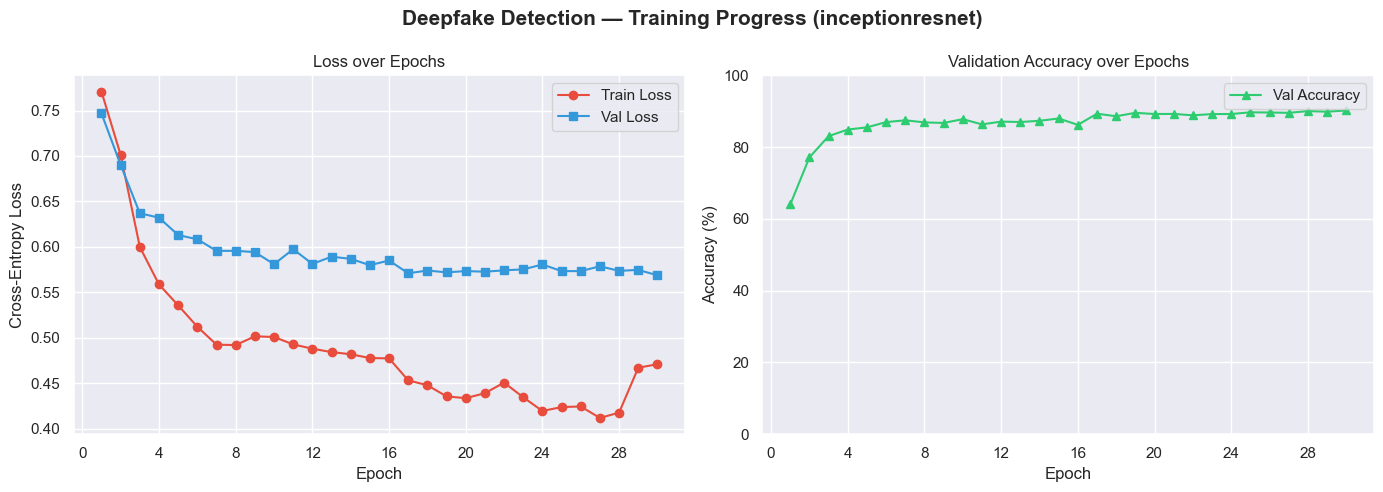

Best val loss: 0.5688 at epoch 30
Best val acc : 90.23% at epoch 30


In [13]:
# ─────────────────────────────────────────────────────────
# CELL 9 — Plot Training Curves
# ─────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid')
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Deepfake Detection — Training Progress ({CONFIG["backbone"]})',
             fontsize=15, fontweight='bold')

ax1.plot(epochs_ran, history['train_loss'], marker='o', label='Train Loss', color='#E74C3C')
ax1.plot(epochs_ran, history['val_loss'],   marker='s', label='Val Loss',   color='#3498DB')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax1.legend()

ax2.plot(epochs_ran, history['val_acc'], marker='^', color='#2ECC71', label='Val Accuracy')
ax2.set_title('Validation Accuracy over Epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 100)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
best_ep = history['val_loss'].index(min(history['val_loss'])) + 1
print(f'Best val loss: {min(history["val_loss"]):.4f} at epoch {best_ep}')
print(f'Best val acc : {max(history["val_acc"]):.2f}% at epoch {history["val_acc"].index(max(history["val_acc"]))+1}')

In [1]:
# ─────────────────────────────────────────────────────────
# CELL 10 — 🔎 Single Image Inference
# ─────────────────────────────────────────────────────────
import os, torch, torch.nn as nn
from torchvision import transforms
from facenet_pytorch import fixed_image_standardization
from PIL import Image

eval_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    fixed_image_standardization,
])

try:
    CLASS_NAMES = {v: k for k, v in train_dataset_base.class_to_idx.items()}
except NameError:
    CLASS_NAMES = {0: 'fake', 1: 'real'}

# Load best model
if os.path.exists(CONFIG['best_model_path']):
    model.load_state_dict(torch.load(CONFIG['best_model_path'], map_location=device))
    print(f'[OK] Loaded best model from {CONFIG["best_model_path"]}')

def predict_image(image_path, model, device):
    img    = Image.open(image_path).convert('RGB')
    tensor = eval_transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad(), autocast(enabled=AMP_ENABLED):
        probs = torch.softmax(model(tensor), dim=1)[0]
    predicted_idx = probs.argmax().item()
    return {
        'label'        : CLASS_NAMES[predicted_idx].upper(),
        'confidence'   : round(probs[predicted_idx].item(), 4),
        'probabilities': {CLASS_NAMES[i]: round(probs[i].item(), 4) for i in range(len(CLASS_NAMES))},
    }

TEST_IMAGE_PATH = r'C:\\Users\\SHINJAN\\Downloads\\deepfake_main\\extracted_faces\\train\\fake\\14_06__walking_down_indoor_hall_disgust__8U9ULZDT_f000785.jpg'
if os.path.exists(TEST_IMAGE_PATH):
    result = predict_image(TEST_IMAGE_PATH, model, device)
    print(f'Verdict: {result["label"]}  ({result["confidence"]*100:.1f}%)')
    print(f'All probs: {result["probabilities"]}')
    img_display = Image.open(TEST_IMAGE_PATH)
    color = '#2ECC71' if result['label'] == 'REAL' else '#E74C3C'
    plt.figure(figsize=(5, 5))
    plt.imshow(img_display)
    plt.title(f'{result["label"]}  ({result["confidence"]*100:.1f}%)', fontsize=14, color=color, fontweight='bold')
    plt.axis('off'); plt.tight_layout(); plt.show()
else:
    print(f'[WARN] Change TEST_IMAGE_PATH to a real image path.')

NameError: name 'CONFIG' is not defined

In [15]:
# ─────────────────────────────────────────────────────────
# CELL 11 — 💾 Save Final Model
# ─────────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
final_path = os.path.join('models', CONFIG['model_save_path'])
torch.save(model.state_dict(), final_path)
print(f'[SAVE] Final model → {final_path}')
print(f'[SAVE] Best model  → {CONFIG["best_model_path"]}')

[SAVE] Final model → models\deepfake_model_final.pt
[SAVE] Best model  → models/best_model.pt


---
# 🚀 Deployment — Real-Time Interview Deepfake Detection
Run these cells **after training is complete** to export the model and spin up the API server.

| Cell | Action |
|---|---|
| Cell D1 | Export weights |
| Cell D2 | Write `server/main.py` (FastAPI) |
| Cell D3 | Write `server/requirements_server.txt` |
| Cell D4 | Start API server |
| Cell D5 | Quick smoke-test |


In [ ]:
# ─────────────────────────────────────────────────────────
# CELL D1 — Export Trained Model
# ─────────────────────────────────────────────────────────
import os, torch

os.makedirs('models', exist_ok=True)

# Load best weights
model.load_state_dict(torch.load(CONFIG['best_model_path'], map_location='cpu'))
model.eval()

# Save plain weights (used by server)
DEPLOY_WEIGHTS = 'models/deepfake_model_weights.pt'
torch.save(model.state_dict(), DEPLOY_WEIGHTS)
print(f'[OK] Weights saved → {DEPLOY_WEIGHTS}')

# Try TorchScript (optional — falls back gracefully)
try:
    scripted = torch.jit.script(model.cpu())
    scripted.save('models/deepfake_model_scripted.pt')
    print('[OK] TorchScript saved → models/deepfake_model_scripted.pt')
except Exception as e:
    print(f'[SKIP] TorchScript failed ({e}) — plain weights are fine')

print('\n✅ Export complete. Run Cell D2 to create the API server.')

In [ ]:
# ─────────────────────────────────────────────────────────
# CELL D2 — Write FastAPI Server (server/main.py)
# ─────────────────────────────────────────────────────────
import os

os.makedirs('server', exist_ok=True)

SERVER_CODE = '''"""
Deepfake Detection API — real-time interview frame analysis
Run: uvicorn main:app --host 0.0.0.0 --port 8000
"""

import io, base64, time
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1, fixed_image_standardization, MTCNN

WEIGHTS_PATH = "../models/deepfake_model_weights.pt"
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE     = 299
CONF_THRESH  = 0.60
print(f"[SERVER] Device: {DEVICE}")

class DeepfakeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = InceptionResnetV1(classify=False, pretrained=\'vggface2\').to(DEVICE)
        self.head = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        ).to(DEVICE)
    def forward(self, x):
        return self.head(self.backbone(x))

model = DeepfakeClassifier()
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()
print(f"[SERVER] Model loaded")

mtcnn = MTCNN(image_size=IMG_SIZE, keep_all=False, min_face_size=40,
              device=DEVICE, post_process=False, margin=20)

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    fixed_image_standardization,
])

CLASS_NAMES = {0: "FAKE", 1: "REAL"}

app = FastAPI(title="Deepfake Detection API", version="1.0")
app.add_middleware(CORSMiddleware, allow_origins=["*"],
                   allow_methods=["*"], allow_headers=["*"])

class FrameRequest(BaseModel):
    image_b64: str

class PredictionResponse(BaseModel):
    label: str
    confidence: float
    uncertain: bool
    face_detected: bool
    latency_ms: float

@app.get("/health")
def health():
    return {"status": "ok", "device": str(DEVICE)}

@app.post("/predict", response_model=PredictionResponse)
def predict(req: FrameRequest):
    t0 = time.perf_counter()
    try:
        img = Image.open(io.BytesIO(base64.b64decode(req.image_b64))).convert("RGB")
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Bad image: {e}")
    face_tensor = mtcnn(img)
    if face_tensor is None:
        return PredictionResponse(label="UNKNOWN", confidence=0.0,
                                  uncertain=True, face_detected=False,
                                  latency_ms=round((time.perf_counter()-t0)*1000,1))
    face_pil = Image.fromarray(face_tensor.permute(1,2,0).byte().cpu().numpy())
    inp = transform(face_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(inp), dim=1)[0]
        pred  = int(torch.argmax(probs))
        conf  = float(probs[pred])
    return PredictionResponse(
        label=CLASS_NAMES[pred], confidence=round(conf,3),
        uncertain=(conf < CONF_THRESH), face_detected=True,
        latency_ms=round((time.perf_counter()-t0)*1000,1)
    )
'''

with open('server/main.py', 'w') as f:
    f.write(SERVER_CODE.strip())
print('[OK] server/main.py written')

In [ ]:
# ─────────────────────────────────────────────────────────
# CELL D3 — Write server/requirements_server.txt
#            & install server dependencies
# ─────────────────────────────────────────────────────────
import subprocess, sys

REQS = """fastapi>=0.110.0
uvicorn[standard]>=0.29.0
python-multipart>=0.0.9
Pillow>=10.2.0
torch>=2.2.0
torchvision>=0.17.0
facenet-pytorch>=2.6.0
numpy>=1.26.0
"""

with open('server/requirements_server.txt', 'w') as f:
    f.write(REQS)
print('[OK] server/requirements_server.txt written')

SERVER_PKGS = ['fastapi', 'uvicorn[standard]', 'python-multipart']
print('Installing server packages...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + SERVER_PKGS)
print('[OK] Server packages installed')

In [ ]:
# ─────────────────────────────────────────────────────────
# CELL D4 — Start API Server
#
# This starts uvicorn in the background so this cell
# returns immediately. The server keeps running until
# the kernel is shut down.
#
# API will be available at:
#   http://localhost:8000/health
#   http://localhost:8000/docs   ← Swagger UI
#   http://localhost:8000/predict
# ─────────────────────────────────────────────────────────
import subprocess, os, sys, time

server_dir = os.path.join(os.getcwd(), 'server')
log_file   = open('server/uvicorn.log', 'w')

proc = subprocess.Popen(
    [sys.executable, '-m', 'uvicorn', 'main:app',
     '--host', '0.0.0.0', '--port', '8000'],
    cwd=server_dir,
    stdout=log_file,
    stderr=subprocess.STDOUT
)

time.sleep(3)   # give server time to start

if proc.poll() is None:
    print(f'[OK]  Server running (PID {proc.pid})')
    print('      Health : http://localhost:8000/health')
    print('      Docs   : http://localhost:8000/docs')
    print('      Predict: POST http://localhost:8000/predict')
    print('\n[INFO] To stop: proc.terminate()')
else:
    print('[ERROR] Server failed to start. Check server/uvicorn.log')
    with open('server/uvicorn.log') as lf:
        print(lf.read())

In [ ]:
# ─────────────────────────────────────────────────────────
# CELL D5 — Smoke Test: send a webcam frame to the API
#
# Captures one frame from your webcam, sends it to the
# running server, and prints the prediction.
# ─────────────────────────────────────────────────────────
import requests, base64, io, cv2
from PIL import Image

API_URL = 'http://localhost:8000/predict'

# ── Capture one frame from webcam ─────────────────────────
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
cap.release()

if not ret:
    print('[WARN] No webcam found — using a blank test image instead')
    img = Image.new('RGB', (640, 480), color=(128,128,128))
else:
    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# ── Encode to base64 ──────────────────────────────────────
buf = io.BytesIO()
img.save(buf, format='JPEG', quality=80)
b64 = base64.b64encode(buf.getvalue()).decode()

# ── Call API ──────────────────────────────────────────────
resp = requests.post(API_URL, json={'image_b64': b64}, timeout=10)
data = resp.json()

print(f"Label       : {data['label']}")
print(f"Confidence  : {data['confidence']*100:.1f}%")
print(f"Face found  : {data['face_detected']}")
print(f"Latency     : {data['latency_ms']} ms")
print(f"Uncertain   : {data['uncertain']}")
if data['label'] == 'REAL':
    print('\n✅ REAL person detected')
elif data['label'] == 'FAKE':
    print('\n🚨 DEEPFAKE detected!')
else:
    print('\n⚠️ No face detected in frame')

In [ ]:
# ───────────────────────────────────────────────────────
# CELL 12 — Test Custom Image / Video
# ───────────────────────────────────────────────────────
import torch
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from realtime_deepfake_detector import RealtimeDeepfakeDetector

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Provide a path to an Image or Video
target_path = r'C:\Users\SHINJAN\Downloads\deepfake_main\extracted_faces\train\fake\14_06__walking_down_indoor_hall_disgust__8U9ULZDT_f000785.jpg'
# target_path = r'C:\Path\To\Your\Video.mp4'  # <-- Uncomment to test a video

# 2. Load the trained model
model_path = r'models/best_model.pt'
detector = RealtimeDeepfakeDetector(model_path=model_path, device=device, threshold=0.60)

cap = cv2.VideoCapture(int(target_path) if target_path.isdigit() else target_path)
if not cap.isOpened():
    print(f"Error: Could not open {target_path}")
else:
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if frame_count <= 1:
        # It's a single image
        ret, frame = cap.read()
        if ret:
            annotated_frame = detector.process_frame(frame)  # Detects face, crops, and analyzes
            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title("Image Analysis")
            plt.show()
    else:
        # It's a video file, process a few frames as preview (or loop via script instead)
        print(f"Video loaded. Total frames: {frame_count}")
        frames_to_show = 5  # Adjust to show more frames
        
        for i in range(frames_to_show):
            ret, frame = cap.read()
            if not ret: break
            
            annotated_frame = detector.process_frame(frame)
            
            clear_output(wait=True)
            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title(f"Video Analysis - Frame {i+1}")
            plt.show()
            print(f"Processing frame {i+1} of {frames_to_show}...")

    cap.release()
